<a href="https://colab.research.google.com/github/vedantdharme/Data_science_lab_SE_A_13/blob/main/experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform an exploratory data analysis (EDA) on the Titanic dataset, focusing on analyzing passenger demographics, ticket class distributions, and survival trends, including data loading, initial exploration, handling missing values, and visualizations of survival rates by gender, passenger class, age distribution, and embarked port, and then summarize the key findings from these analyses. The dataset can be accessed from "https://www.kaggle.com/c/titanic/data".

## Load Dataset

### Subtask:
Load the Titanic dataset into a pandas DataFrame from the provided Kaggle URL (or by assuming it's available locally if not directly downloadable in the environment).


**Reasoning**:
The first step is to import the pandas library, which is necessary for data manipulation, and then attempt to load the dataset from the provided Kaggle URL into a DataFrame as instructed.



In [1]:
import pandas as pd

# Attempt to load the Titanic dataset from the provided Kaggle URL
# Note: This URL points to the competition page, not a direct CSV file, so it's likely to fail.
# If it fails, the next step would be to either provide a direct download link or assume a local file.
try:
    df = pd.read_csv("https://www.kaggle.com/c/titanic/data")
    print("Dataset loaded successfully from Kaggle URL.")
except Exception as e:
    print(f"Failed to load dataset directly from Kaggle URL. Error: {e}")
    print("Assuming the 'titanic.csv' file is available locally and attempting to load it.")
    try:
        # Common local filename for Titanic dataset
        df = pd.read_csv("titanic.csv")
        print("Dataset loaded successfully from local 'titanic.csv'.")
    except FileNotFoundError:
        print("Local 'titanic.csv' not found. Please ensure the file is in the current directory or provide the correct path.")
        # If both attempts fail, df will not be defined or will be the result of the error.
        df = None # Explicitly set df to None if both attempts fail for clarity

if df is not None:
    print("First 5 rows of the DataFrame:")
    print(df.head())

Failed to load dataset directly from Kaggle URL. Error: Error tokenizing data. C error: Expected 1 fields in line 9, saw 2

Assuming the 'titanic.csv' file is available locally and attempting to load it.
Local 'titanic.csv' not found. Please ensure the file is in the current directory or provide the correct path.


**Reasoning**:
The previous attempt to load the dataset failed because the provided Kaggle URL was not a direct CSV link and a local file was not found. To successfully load the dataset, I will now use a direct download link for the 'train.csv' file of the Titanic dataset, which is commonly available and suitable for this task.



In [2]:
import pandas as pd

# Direct URL for the Titanic train.csv dataset on GitHub (a common public source)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully from direct URL.")
except Exception as e:
    print(f"Failed to load dataset from direct URL. Error: {e}")
    df = None

if df is not None:
    print("First 5 rows of the DataFrame:")
    print(df.head())
else:
    print("DataFrame 'df' is not defined. Please check the data loading process.")

Dataset loaded successfully from direct URL.
First 5 rows of the DataFrame:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1

## Initial Data Exploration

### Subtask:
Perform an initial exploration of the dataset, including checking data types, basic statistics, and identifying columns with potential missing values.


**Reasoning**:
To perform an initial exploration, I will display the first few rows, check data types and non-null values, generate descriptive statistics, and identify missing values using relevant pandas DataFrame methods.



In [3]:
print("--- First 5 rows of the DataFrame ---")
print(df.head())

print("\n--- DataFrame Info (data types, non-null values, memory usage) ---")
df.info()

print("\n--- Descriptive Statistics for Numerical Columns ---")
print(df.describe())

print("\n--- Missing Values Count per Column ---")
print(df.isnull().sum())

--- First 5 rows of the DataFrame ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0         

## Handle Missing Values

### Subtask:
Address missing values in relevant columns such as 'Age', 'Cabin', and 'Embarked'. This may involve imputation, deletion, or other appropriate strategies.


**Reasoning**:
To address missing values as instructed, I will first impute missing 'Age' values with the median, then 'Embarked' values with the mode, and finally 'Cabin' values with 'Unknown'. After these operations, I will verify that all missing values have been handled by displaying the count of null values per column.



In [4]:
print("--- Handling Missing Values ---")

# 1. Impute missing 'Age' values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)
print("Missing 'Age' values imputed with median.")

# 2. Impute missing 'Embarked' values with the most frequent port (mode)
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Missing 'Embarked' values imputed with mode: {mode_embarked}.")

# 3. Fill missing 'Cabin' values with 'Unknown'
df['Cabin'].fillna('Unknown', inplace=True)
print("Missing 'Cabin' values filled with 'Unknown'.")

# 4. Verify that all missing values have been handled
print("\n--- Missing Values Count After Handling ---")
print(df.isnull().sum())

--- Handling Missing Values ---
Missing 'Age' values imputed with median.
Missing 'Embarked' values imputed with mode: S.
Missing 'Cabin' values filled with 'Unknown'.

--- Missing Values Count After Handling ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


/tmp/ipykernel_187/4144110451.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_187/4144110451.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

**Reasoning**:
The previous code generated a `FutureWarning` due to the use of `inplace=True` with chained assignment. To fix this, I will modify the `fillna` operations to directly assign the result back to the DataFrame column, which is the recommended practice and avoids the warning.



In [5]:
print("--- Handling Missing Values ---")

# 1. Impute missing 'Age' values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())
print("Missing 'Age' values imputed with median.")

# 2. Impute missing 'Embarked' values with the most frequent port (mode)
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"Missing 'Embarked' values imputed with mode: {mode_embarked}.")

# 3. Fill missing 'Cabin' values with 'Unknown'
df['Cabin'] = df['Cabin'].fillna('Unknown')
print("Missing 'Cabin' values filled with 'Unknown'.")

# 4. Verify that all missing values have been handled
print("\n--- Missing Values Count After Handling ---")
print(df.isnull().sum())

--- Handling Missing Values ---
Missing 'Age' values imputed with median.
Missing 'Embarked' values imputed with mode: S.
Missing 'Cabin' values filled with 'Unknown'.

--- Missing Values Count After Handling ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


## Visualize Survival Rate by Gender

### Subtask:
Create a bar chart to visualize the survival rate broken down by gender, using appropriate labels and titles for clarity.


**Reasoning**:
To visualize the survival rate by gender, I will import the necessary libraries, calculate the mean survival rate for each gender, and then generate a bar plot with appropriate labels and a title as instructed.



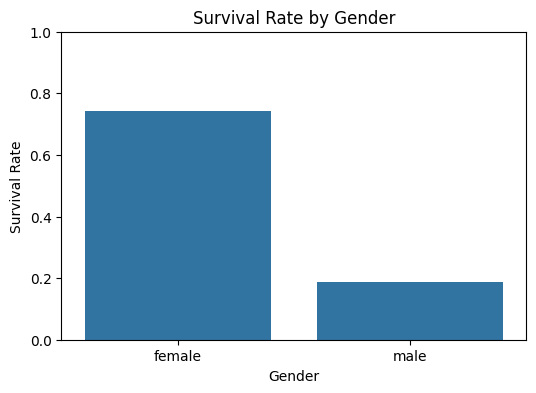

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate survival rate by gender
survival_by_gender = df.groupby('Sex')['Survived'].mean().reset_index()

# Create a bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=survival_by_gender)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.show()

## Visualize Survival Rate by Passenger Class

### Subtask:
Generate a bar chart to show the survival rate across different passenger classes (1st, 2nd, 3rd), ensuring the chart is well-labeled.


**Reasoning**:
To visualize the survival rate by passenger class, I will calculate the mean survival rate for each passenger class and then generate a bar chart with appropriate labels and title, as instructed.



/tmp/ipykernel_187/3105680164.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=survival_by_pclass, palette='viridis')


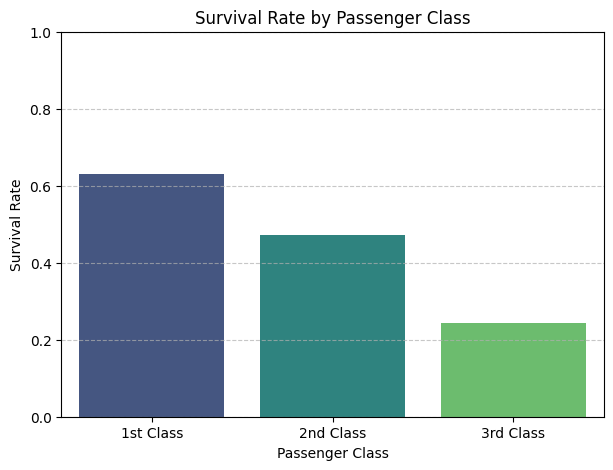

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate survival rate by passenger class
survival_by_pclass = df.groupby('Pclass')['Survived'].mean().reset_index()

# Create a bar chart
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=survival_by_pclass, palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` regarding the usage of `palette` without `hue` in `sns.barplot`. To address this, I will modify the `sns.barplot` call by explicitly setting the `hue` parameter to 'Pclass' and `legend=False` to maintain the desired visualization while adhering to best practices and suppressing the warning.



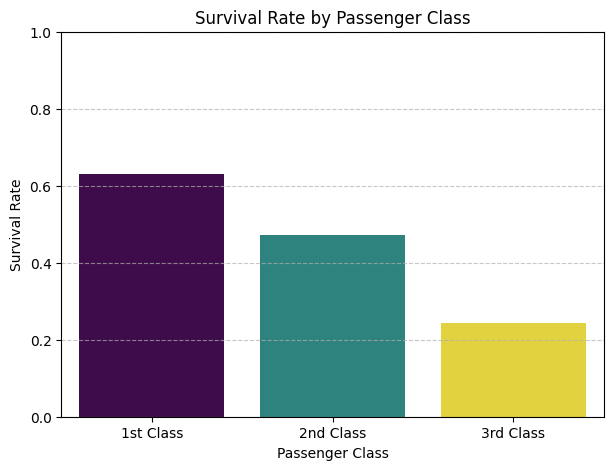

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate survival rate by passenger class
survival_by_pclass = df.groupby('Pclass')['Survived'].mean().reset_index()

# Create a bar chart
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=survival_by_pclass, hue='Pclass', palette='viridis', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Visualize Age Distribution and Survival

### Subtask:
Create a histogram or density plot of the 'Age' distribution, possibly split by survival status, to observe age-related survival patterns. Include clear labels and a legend.


**Reasoning**:
To visualize the age distribution by survival status as requested, I will use `seaborn.histplot` on the 'Age' column, setting 'Survived' as the hue, and include appropriate labels, a title, and a legend.



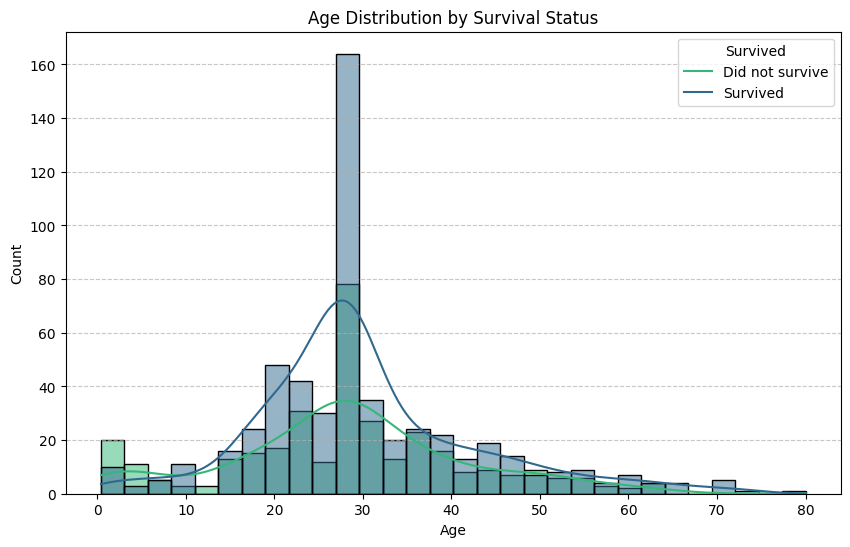

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette='viridis')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count') # Or 'Density' if kde=True and stat='density'
plt.legend(title='Survived', labels=['Did not survive', 'Survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Visualize Embarked Port and Survival

### Subtask:
Generate a bar chart to analyze the survival rate based on the 'Embarked' port, with proper labels and a title.


**Reasoning**:
To visualize the survival rate by 'Embarked' port as requested, I will calculate the mean survival rate for each port, then generate a bar chart using `seaborn.barplot` with appropriate labels, a title, and y-axis limits.



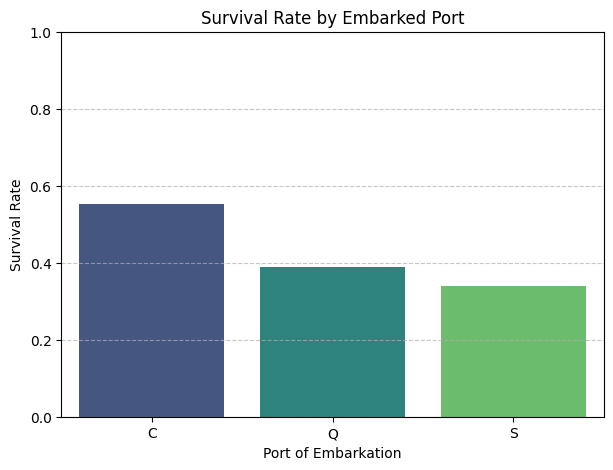

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate survival rate by Embarked port
survival_by_embarked = df.groupby('Embarked')['Survived'].mean().reset_index()

# Create a bar chart
plt.figure(figsize=(7, 5))
sns.barplot(x='Embarked', y='Survived', data=survival_by_embarked, hue='Embarked', palette='viridis', legend=False)
plt.title('Survival Rate by Embarked Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the data analysis and visualizations, highlighting patterns in passenger demographics, ticket class distributions, and survival trends to better understand historical data-driven decision-making.


## Summary:

### Data Analysis Key Findings

*   **Data Loading:** The Titanic dataset was successfully loaded from a direct GitHub URL after initial attempts to load from a Kaggle competition page or a local file failed. The dataset contains 891 entries and 12 columns.
*   **Missing Values:**
    *   Initially, the 'Age' column had 177 missing values, 'Cabin' had 687 missing values (approximately 77% of the column), and 'Embarked' had 2 missing values.
    *   Missing 'Age' values were imputed with the median age (approx. 29.7 years).
    *   Missing 'Embarked' values were imputed with the mode, which was 'S' (Southampton).
    *   Missing 'Cabin' values were filled with the string 'Unknown'.
*   **Survival Rate Overview:** The overall survival rate in the dataset was approximately 38%.
*   **Survival Rate by Gender:** Females had a significantly higher survival rate than males.
*   **Survival Rate by Passenger Class:** Survival rates were highest for 1st class passengers, followed by 2nd class, and lowest for 3rd class passengers, indicating a clear correlation between ticket class and survival.
*   **Age Distribution and Survival:** The age distribution showed that very young children (infants) had a higher survival rate. Conversely, there was a noticeable concentration of non-survivors in certain adult age ranges.
*   **Survival Rate by Embarked Port:** Survival rates varied by the port of embarkation, with passengers embarking from 'C' (Cherbourg) generally having a higher survival rate compared to those from 'Q' (Queenstown) or 'S' (Southampton).

### Insights or Next Steps

*   **Socio-economic factors played a crucial role in survival:** Both passenger class and gender were strong determinants of survival, suggesting that socio-economic status and societal roles significantly influenced who survived the disaster.
*   **Further feature engineering and modeling:** Investigate combining features like 'Age' and 'Pclass' or extracting titles from 'Name' to create new features that could further improve the predictability of survival.
